In [3]:
#多层感知机从零开始实现
import torch
import torch.nn as nn
from d2l import torch as d2l
from torchvision import datasets,transforms
from torch.utils.data import DataLoader

In [5]:
transform = transforms.ToTensor()
train_dataset = datasets.FashionMNIST(
    root = "D:/dataset/fashionmnist",
    train = True,
    transform = transform,
    download = True
)
test_dataset = datasets.FashionMNIST(
    "D:/dataset/fashionmnist",
    train = False,
    transform = transform,
    download = True          
)
train_iter = DataLoader(train_dataset,batch_size=256,shuffle=True)
test_iter = DataLoader(test_dataset,batch_size = 256,shuffle = False)

In [24]:
#定义激活函数，非线性变换
def relu(X):
    a=torch.zeros_like(X)
    return torch.max(a,X)

In [41]:
num_inputs,num_outputs,num_hiddens=784,10,100
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.w1=nn.Parameter(torch.randn(num_inputs,num_hiddens,requires_grad=True))
        self.b1=nn.Parameter(torch.zeros(num_hiddens,requires_grad=True))
        self.w2=nn.Parameter(torch.randn(num_hiddens,num_outputs,requires_grad=True))
        self.b2=nn.Parameter(torch.zeros(num_outputs,requires_grad=True))

    def forward(self,X):
        X=X.reshape((-1,num_inputs))
        H = relu(X@self.w1+self.b1)
        return (H@self.w2+self.b2)

In [42]:
net = MLP()
loss = nn.CrossEntropyLoss()

loss 0.686, train acc 0.769, test acc 0.755
90994.1 examples/sec on cpu


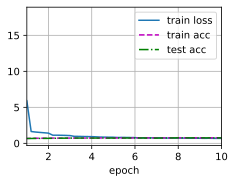

In [44]:
num_epochs,lr = 10,0.1
updater = torch.optim.SGD(params,lr=lr)
device = torch.device("cpu")
d2l.train_ch6(net,train_iter,test_iter,num_epochs,lr,device)

In [ ]:
#多层感知机的简洁实现
